In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We do the same calculations that we did in "btc_std_calc_2_states.ipynb". Refer to that.

In [36]:
# Refer to "16_states_transitions_and_means.ipynb" for this.
P = np.genfromtxt("mat_16_states.csv")

$$\pi = [0.002312, 0.008625, 0.039261, 0.424289, 0.476712, 0.038519,
       0.008175, 0.002106]

In [37]:
# Refer to "32_states_transitions_and_means.ipynb"
pi = np.genfromtxt("pi_16_states.csv",delimiter=",")

In [38]:
pi

array([0.027231, 0.009277, 0.012495, 0.017704, 0.0267  , 0.046889,
       0.103364, 0.230965, 0.263731, 0.112912, 0.05243 , 0.029943,
       0.018886, 0.012599, 0.009154, 0.02572 ])

In [39]:
Pi = np.vstack([pi]*16)

In [40]:
# Refer to "16_states_transitions_and_means.ipynb" for this.
a_star = 0.187600

In [41]:
a = np.array([-20.0,-17.5,-15.0,-12.5,-10.0,-7.5,-5,-2.5,2.5,5.0,7.5,10.0,12.5,15.0,17.5,20])

In [42]:
b = np.array(a-a_star)

In [43]:
b

array([-20.1876, -17.6876, -15.1876, -12.6876, -10.1876,  -7.6876,
        -5.1876,  -2.6876,   2.3124,   4.8124,   7.3124,   9.8124,
        12.3124,  14.8124,  17.3124,  19.8124])

$$ g:= (P + \Pi^* -I){^-1} b$$

In [44]:
A= np.linalg.inv(P + Pi - np.eye(16))

In [45]:
g = np.matmul(A,b)


In [46]:
print(g)

[ 23.95759291  21.57966342  19.35024775  16.4789729   13.64533807
  10.41598882   6.8146258    4.04105543  -3.37049251  -6.15860797
  -9.86308703 -13.28525242 -16.38268298 -19.27141871 -21.93917577
 -24.27240474]


In [47]:
v = np.zeros(len(g))

In [48]:
for i in range(len(v)):
    s = 0
    for j in range(len(v)):
        s += ((g[j]-g[i])**2)* P[i,j]
    s_2=0
    for j in range(len(v)):
        s_2 += (g[j]-g[i])*P[i,j]
    v[i] = b[i]**2 + s - 2*(b[i])*s_2

In [49]:
print(v)

[207.84467253 150.18182114 144.5415187  142.32206485 127.03095714
 109.90906386  87.99310601  63.84813322  63.14277129  85.27336105
 105.59849311 122.23162464 132.45788037 143.46012437 153.31140812
 204.19333439]


$$\sigma ^2 = \sum \pi _i v(i) $$

In [50]:
sigma = np.sqrt(np.matmul(pi,v))

In [51]:
print(sigma)

9.497786511038761


We need $$\sigma \sqrt{(\frac{\lambda }{1-\hat{h}})}$$

We have $$\lambda = 0.00031458686590702084, a =  0.02230285826488395, b =  0.04458713874443153$$

In [52]:
lamb = 0.16508945342301887

a=0.011477956127453995

b = 0.20470834799305934

We have $$h(t,z) = z a \exp(-bt)$$

$$H(z):= \int _0 ^ \infty h(t,z) dt$$ 

Thus in our case we have $$H(z) = \frac{az}{b}$$

Now we take the density of Z as $f(z)$

An observation before gave us $$f(z) = \frac{1}{\sqrt{2 \pi \sigma ^2}} \exp({-1/2 \frac{(z-\mu)^2}{\sigma ^2} })$$

When we fitted , got $$\mu = 13.329567797401769,$$

In [53]:
mu = 13.329567797401769


$$\hat{h} := \int{H(z)f(z)} dz$$

In [54]:
h_hat = a/b * mu

In [55]:
print(h_hat)

0.7473862003013596


In [56]:
par =  (sigma * np.sqrt(lamb/(1-h_hat)))

In [57]:
print(par)

7.678095906401425


In [58]:
data_interval =  np.linspace(0, +1200, 100)

In [59]:
std_results = np.genfromtxt("std_results.csv",delimiter=",")
x = std_results[:,0]
y = std_results[:,1]



Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


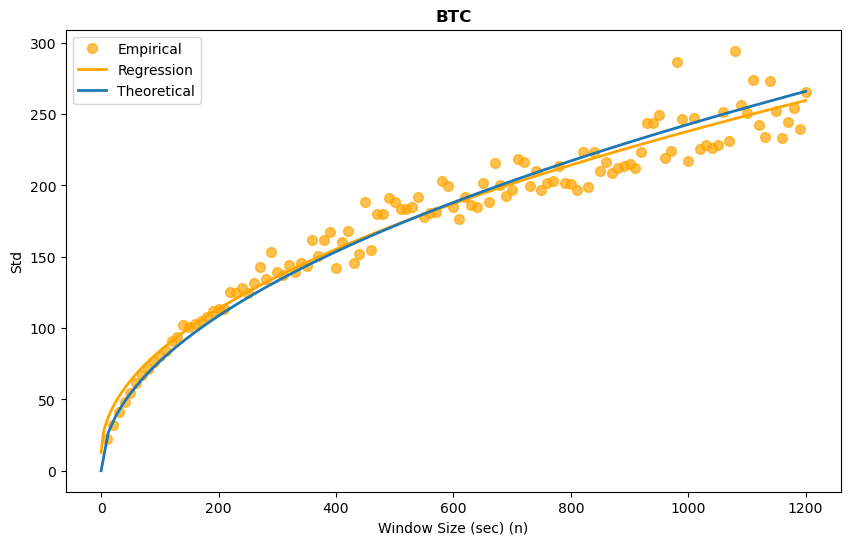

In [60]:
# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="orange",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2)

plt.plot(data_interval,np.sqrt(data_interval)*par,label = "Theoretical",linewidth = 2 )




plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()

In [61]:
y_hat = np.sqrt(x)*par

In [62]:
MSE = np.array([(y[i]-y_hat[i])**2   for i in range(len(y_hat))])

In [63]:
MSE = np.sum(MSE) / len(MSE)

In [64]:
print(f"Mean square error: {MSE}")

Mean square error: 177.0789469841924


In [65]:
print(f"Percentage error:%{((par-7.123004)/7.123004)*100}")

Percentage error:%7.792946717444284
